# Compare Loop 3 and Loop 2.5 on Monocyte Enrichment.

## Prepare the Notebook.

### Import the Libraries.

In [9]:
import joblib
import os
import sys
import yaml

import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import numpy as np
import pandas as pd
from scipy.spatial.distance import cdist
from scipy.stats import gaussian_kde
import seaborn as sns
from tqdm import tqdm

### Read Annotation Configurations from Loop 2.5.

In [10]:
config2_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus.yaml"
with open(config2_path, "r") as fb:
    annot2_dict = yaml.safe_load(fb)
protocol_cols2 = annot2_dict["protocol_columns"]
resc_protocol_cols2 = [f"{c}:rescaled" for c in protocol_cols2]

### Read Annotation Configurations from Loop 3.

In [11]:
config3_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/annotation/bloodplus_loop3.yaml"
with open(config3_path, "r") as fb:
    annot3_dict = yaml.safe_load(fb)
protocol_cols3 = annot3_dict["protocol_columns"]
resc_protocol_cols3 = [f"{c}:rescaled" for c in protocol_cols3]

### Read Constraints Configurations from Loop 2.5.

In [12]:
constraints2_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols.yaml"
with open(constraints2_config_path, "r") as fb:
    constraints2_config = yaml.safe_load(fb)
ubound2_dict = constraints2_config["ubound_dict"]
lbound2_dict = constraints2_config["lbound_dict"]


### Read Constraints Configurations from Loop 3.

In [13]:
constraints3_config_path = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/collab-goettgens-SFC/inverse/loss_guidance/config/constraints/default_all_cols_loop3.yaml"
with open(constraints3_config_path, "r") as fb:
    constraints3_config = yaml.safe_load(fb)
ubound3_dict = constraints3_config["ubound_dict"]
lbound3_dict = constraints3_config["lbound_dict"]


## Read Optimization Results.

### Define Function to Read Results Directory in a Parallelized Way.

In [14]:
def get_opt_df(
    res_base_dir
):
    all_runs = []

    opt_modes_list = os.listdir(res_base_dir)

    for opt_leaf_dir in opt_modes_list:
        opt_dir = os.path.join(res_base_dir, opt_leaf_dir)
        cts_list = os.listdir(opt_dir)

        for ct_leaf_dir in cts_list:
            ct_dir = os.path.join(opt_dir, ct_leaf_dir)
            runs_list = os.listdir(ct_dir)

            for run_leaf_dir in runs_list:
                run_dir = os.path.join(ct_dir, run_leaf_dir)
                csv_path = os.path.join(run_dir, "candidates.csv")            
                all_runs.append(
                    {
                        "target_ct": ct_leaf_dir,
                        "run_id": run_leaf_dir,
                        "opt_id": opt_leaf_dir,
                        "csv_path": csv_path,
                    }
                )
    def _load_run(run_dict):
        target_ct = run_dict["target_ct"]
        run_id = run_dict["run_id"]
        opt_id = run_dict["opt_id"]
        csv_path = run_dict["csv_path"]

        df = pd.read_csv(csv_path)
        df["run_id"] = run_id
        df["opt_id"] = opt_id
        df["target_ct"] = target_ct
        return df
        
    n_jobs = 100
    data = joblib.Parallel(n_jobs=n_jobs)(joblib.delayed(_load_run)(run_dict) for run_dict in all_runs)
    return pd.concat(data, ignore_index=True)

### Read Optimization Data from Looop 2.5.

In [15]:
res_base_dir2 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop2p5_replicate"
opt_df2 = get_opt_df(res_base_dir2)
opt_df2

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:gm-csf_[ng_ml],cfg:constraints:ubound_dict:tpo_[ng_ml],cfg:constraints:ubound_dict:um171_[nm],cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml]
0,EryPro:2026-06-26_04-11-58_cee7e426:0,12.124698,2.182126,84.65543,0.000000,0.862212,0.000000,0.000000,0.006725,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,EryPro:2026-06-26_04-11-58_cee7e426:1,2.807606,0.016716,289.35630,175.749700,0.000000,0.000000,116.696170,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,EryPro:2026-06-26_04-11-58_cee7e426:2,10.091269,2.569805,550.93555,782.041000,0.045200,47.781437,0.066810,0.000000,0.001518,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,EryPro:2026-06-26_04-11-58_cee7e426:3,9.844760,2.468653,774.40030,0.063012,0.552813,47.939167,0.052818,0.296393,0.015844,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,EryPro:2026-06-26_04-11-58_cee7e426:4,9.687686,2.489527,824.40380,1212.362300,0.025199,56.669476,0.000000,0.032299,0.015634,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
152045,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:45,10.852804,2.487143,551.91125,773.857000,0.000000,48.539486,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152046,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:46,11.335658,2.366785,1005.68230,578.002700,0.000000,24.263077,0.094563,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152047,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:47,10.607610,1.946655,742.47614,1444.148200,0.000000,39.061016,0.000000,0.000000,1.770090,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
152048,CD14Mono:2026-06-25_22-11-07_f4f6f2d6:48,10.221303,2.617736,347.98157,645.587950,0.000000,43.864124,0.000000,0.000000,0.040813,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


### Read Optimization Data from Looop 3.

In [16]:
res_base_dir3 = "/lustre/groups/ml01/workspace/lorenzo.consoli/projects/SFC_cambridge/output/inverse/loss_guidance/loop3_replicate"
opt_df3 = get_opt_df(res_base_dir3)
opt_df3

,sample_id,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],...,cfg:constraints:ubound_dict:um729_[µm],cfg:constraints:ubound_dict:sr1_[nm],cfg:constraints:ubound_dict:scf_[ng_ml],cfg:constraints:ubound_dict:butyzamide_[nm],cfg:constraints:ubound_dict:retinoic_acid_[µm],cfg:constraints:ubound_dict:ldl_[ng_ml],cfg:constraints:ubound_dict:il3_[ng_ml],cfg:constraints:ubound_dict:il7_[ng_ml],cfg:constraints:ubound_dict:mcsf_[ng_ml],cfg:constraints:ubound_dict:ly_cocktail_[ul/well]
0,CD16Mono:2026-06-26_23-29-58_dfbf9997:0,4.502639,0.184500,4.242442,0.197834,1.214640,0.487637,8.061746,0.179712,0.006153,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1,CD16Mono:2026-06-26_23-29-58_dfbf9997:1,10.106312,2.453917,738.088200,1430.027600,0.000000,49.336456,0.088904,0.131064,0.122932,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,CD16Mono:2026-06-26_23-29-58_dfbf9997:2,10.268727,2.255093,66.239860,0.060196,0.091318,47.117905,0.074269,0.623657,0.054582,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,CD16Mono:2026-06-26_23-29-58_dfbf9997:3,9.620847,2.409060,259.914370,957.807860,0.088218,55.726196,0.377347,0.000000,11.627491,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
4,CD16Mono:2026-06-26_23-29-58_dfbf9997:4,9.052049,2.468425,1285.206400,1184.954100,0.069181,46.737404,0.000000,0.091902,0.111592,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
107545,CD14Mono:2026-06-27_16-48-26_4484adb6:45,10.122643,1.517220,373.246220,1096.802500,0.000000,40.097680,0.000000,0.493058,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107546,CD14Mono:2026-06-27_16-48-26_4484adb6:46,10.823056,2.675481,721.396670,0.478380,1.125787,3.693521,0.000000,0.000000,0.190955,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107547,CD14Mono:2026-06-27_16-48-26_4484adb6:47,11.561108,1.715770,734.997560,897.702400,0.517068,25.869467,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
107548,CD14Mono:2026-06-27_16-48-26_4484adb6:48,10.204626,2.172140,1156.524000,0.000000,1.804664,55.672585,0.000000,0.000000,0.000000,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


## Filter Optimization Data on Experimental Constraints.

### Define Function to Filter Optimization Data Based on Experimental Constraints.

In [17]:
def filter_opt_results(candidates_df, lbound_dict, ubound_dict, margin = 0.1):
    # ----  Target Markers Loop ----
    print("---- Filtering Results ----")
    # define mask for all columns
    marker_mask = np.full(candidates_df.shape[0], True)

    # ----  Protocol Columns Loop ----
    for col, col_ubound in ubound_dict.items():
        # get col bounds
        col_lbound = lbound_dict[col]
        print(f"\t\t---- Processing Column {col} -> U: {col_ubound}, L: {col_lbound} ----")

        # get col values and mask
        col_values = candidates_df[col]
        col_mask_ubound_mask = col_values <= col_ubound*(1 + margin)
        col_mask_lbound_mask = col_values >= col_lbound*(1 - margin)

        # get masks for current column
        old_mask = marker_mask
        lbound_marker_mask = marker_mask & col_mask_lbound_mask
        ubound_marker_mask = marker_mask & col_mask_ubound_mask
        marker_mask = marker_mask & col_mask_ubound_mask & col_mask_lbound_mask

        # get number of solutions
        n_previously_accepted_solutions = old_mask.sum()
        n_accepted_solutions = marker_mask.sum()
        n_solutions_passing_ubound = col_mask_ubound_mask.sum()
        n_solutions_passing_lbound = col_mask_lbound_mask.sum()
        n_solutions_passing_ubound_and_previous_constraints = ubound_marker_mask.sum()
        n_solutions_passing_lbound_and_previous_constraints = lbound_marker_mask.sum()
        print(f"\t\t\t --- Number Previously Accepted Solutions {n_previously_accepted_solutions} ---")
        print(f"\t\t\t --- Number Currently Accepted Solutions {n_accepted_solutions} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound {n_solutions_passing_ubound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound {n_solutions_passing_lbound} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Upper Bound and Previous Constraints {n_solutions_passing_ubound_and_previous_constraints} ---")
        print(f"\t\t\t --- Number of Solution Satisfying Lower Bound and Previous Constraints {n_solutions_passing_lbound_and_previous_constraints} ---")


        # write values for constraint on current column
        candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
        candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask

    # write values for all constraints
    n_all_solutions = candidates_df.shape[0]
    n_accepted_solutions = marker_mask.sum()
    candidates_df["passes_constraints:all"] = marker_mask

    print(f"\t\t\t--- Finished, Out of {n_all_solutions} there are {n_accepted_solutions} Passing with Margin {margin} ----")
    return candidates_df

### Filter Optimization Data from Loop 2.5.

In [18]:
opt_df2 = filter_opt_results(opt_df2, lbound2_dict, ubound2_dict)
opt_df2_filt = opt_df2[opt_df2["passes_constraints:all"]]
opt_df2_filt.shape[0] / opt_df2.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 152050 ---
			 --- Number Currently Accepted Solutions 137141 ---
			 --- Number of Solution Satisfying Upper Bound 137141 ---
			 --- Number of Solution Satisfying Lower Bound 152050 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 137141 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 152050 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 137141 ---
			 --- Number Currently Accepted Solutions 127536 ---
			 --- Number of Solution Satisfying Upper Bound 139725 ---
			 --- Number of Solution Satisfying Lower Bound 152050 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 127536 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 137141 ---
		---- Processing Column um171_[nm] ->

0.5395198947714568

### Filter Optimization Data from Loop 3.

In [19]:
opt_df3 = filter_opt_results(opt_df3, lbound3_dict, ubound3_dict)
opt_df3_filt = opt_df3[opt_df3["passes_constraints:all"]]
opt_df3_filt.shape[0] / opt_df3.shape[0]

---- Filtering Results ----
		---- Processing Column gm-csf_[ng_ml] -> U: 10.0, L: 0.0 ----
			 --- Number Previously Accepted Solutions 107550 ---
			 --- Number Currently Accepted Solutions 92712 ---
			 --- Number of Solution Satisfying Upper Bound 92712 ---
			 --- Number of Solution Satisfying Lower Bound 107550 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 92712 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 107550 ---
		---- Processing Column tpo_[ng_ml] -> U: 2.5, L: 0.0 ----
			 --- Number Previously Accepted Solutions 92712 ---
			 --- Number Currently Accepted Solutions 86106 ---
			 --- Number of Solution Satisfying Upper Bound 98052 ---
			 --- Number of Solution Satisfying Lower Bound 107550 ---
			 --- Number of Solution Satisfying Upper Bound and Previous Constraints 86106 ---
			 --- Number of Solution Satisfying Lower Bound and Previous Constraints 92712 ---
		---- Processing Column um171_[nm] -> U: 1120

/tmp/ipykernel_1684068/1770590638.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  candidates_df[f"passes_constraints:{col}:lbound"] = col_mask_ubound_mask
/tmp/ipykernel_1684068/1770590638.py:40: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  candidates_df[f"passes_constraints:{col}:ubound"] = col_mask_ubound_mask
/tmp/ipykernel_1684068/1770590638.py:41: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all colum

0.4303300790330079

## Get Optimization Data for Monocytes Targets.

### Subset the Optimization Data for the Target Cell Types.

In [20]:
ct_dfs_dict = {}
target_cts = ["CD14Mono", "CD16Mono"]

for ct in target_cts:
    ct_df2 = opt_df2_filt[opt_df2_filt["target_ct"] == ct] 
    ct_df3 = opt_df3_filt[opt_df3_filt["target_ct"] == ct]
    
    ct_dfs_dict[ct] = {
        "Loop 2.5": ct_df2,
        "Loop 3": ct_df3,
    }

### Define Function for Plotting.

In [21]:
def plot_distribution(
    df,
    col_name,
    source_col="Source",
    loop0_key="Loop 0",
    loop1_key="Loop 1",
    bins=5,
    figsize=(4.5, 4.5),
    dpi=300,
    save_path=None,
    legend_path=None,
    xlabel=None,
    ylabel="Density (symlog scale)",
    yscale='symlog',
    linthresh=0.1,
    palette=None,
    naked=False,
    remove_ax_titles=True,
):
    if palette is None:
        palette = cmap

    color0 = palette[loop0_key]
    color1 = palette[loop1_key]

    mask0 = df[source_col] == loop0_key
    mask1 = df[source_col] == loop1_key
    data0 = df.loc[mask0, col_name].values
    data1 = df.loc[mask1, col_name].values

    # ----- figure -----
    plt.figure(figsize=figsize, dpi=dpi, facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # histograms
    ax.hist(data0, bins=bins, density=True, alpha=0.4,
            facecolor=color0, edgecolor='black', linewidth=0.4, zorder=2)
    ax.hist(data1, bins=bins, density=True, alpha=0.4,
            facecolor=color1, edgecolor='black', linewidth=0.4, zorder=2)

    # KDE
    x_min = min(data0.min(), data1.min())
    x_max = max(data0.max(), data1.max())
    pad = 0.05 * (x_max - x_min) if (x_max - x_min) != 0 else 0.1
    x_grid = np.linspace(x_min - pad, x_max + pad, 300)
    kde0 = gaussian_kde(data0)
    kde1 = gaussian_kde(data1)
    ax.plot(x_grid, kde0(x_grid), color=color0, linewidth=2.5, zorder=3)
    ax.plot(x_grid, kde1(x_grid), color=color1, linewidth=2.5, zorder=3)

    # scale
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=linthresh)
    else:
        ax.set_yscale(yscale)

    # ----- naked style: thick spines, ticks visible but no labels -----
    if naked:
        # make all four spines visible and thick
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)        # extra thick

        # set tick marks with length/width but hide labels
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.tick_params(axis='both', which='major',
                       length=8, width=2, color='black',
                       labelleft=False, labelbottom=False)   # no text

    else:
        # standard styling: left & bottom spines only, labels, ticks
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.tick_params(axis='both', which='major',
                       labelsize=13, length=8, width=2, color='black')
        ax.set_xlabel(xlabel if xlabel else col_name, fontsize=14, fontweight='bold')
        ax.set_ylabel(ylabel, fontsize=14, fontweight='bold')
        sns.despine()


    # remove axis titles (if any)
    if remove_ax_titles:
        ax.set_xlabel('')
        ax.set_ylabel('')
        ax.set_title('')


    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()

    # legend only for non‑naked plots
    if legend_path:
        legend_handles = [
            mpatches.Patch(color=color0, alpha=0.4, label=loop0_key),
            mpatches.Patch(color=color1, alpha=0.4, label=loop1_key)
        ]
        fig_leg = plt.figure(figsize=(2.2, 1.2), dpi=dpi)
        ax_leg = fig_leg.add_subplot(111)
        ax_leg.axis('off')
        ax_leg.legend(handles=legend_handles, loc='center', frameon=False,
                      title='Source', title_fontsize=10, fontsize=9)
        fig_leg.savefig(legend_path, bbox_inches='tight', dpi=dpi)
        plt.show()


### Visualize the Improvement in Target Cell Type Enrichment.

In [25]:
ct_dfs_dict["CD14Mono"].keys()

dict_keys(['Loop 2.5', 'Loop 3'])

CD14Mono
	Loop 2.5 threshold: 0.0056 -> 2904 kept
	Loop 3 threshold:   0.0086 -> 3713 kept


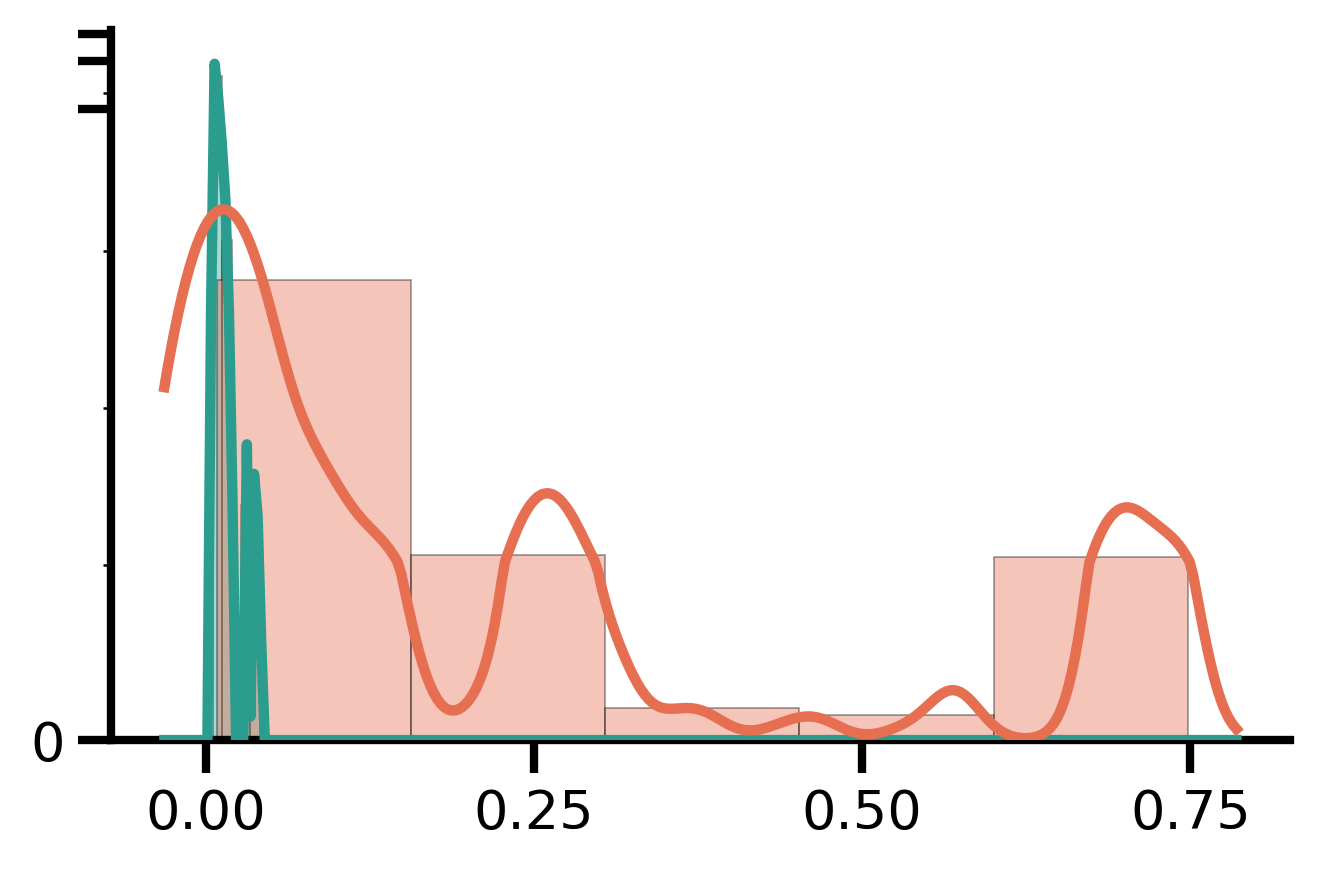

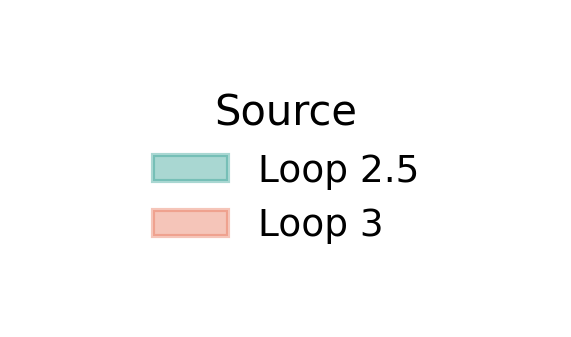

CD16Mono
	Loop 2.5 threshold: 0.0151 -> 5654 kept
	Loop 3 threshold:   0.0588 -> 2421 kept


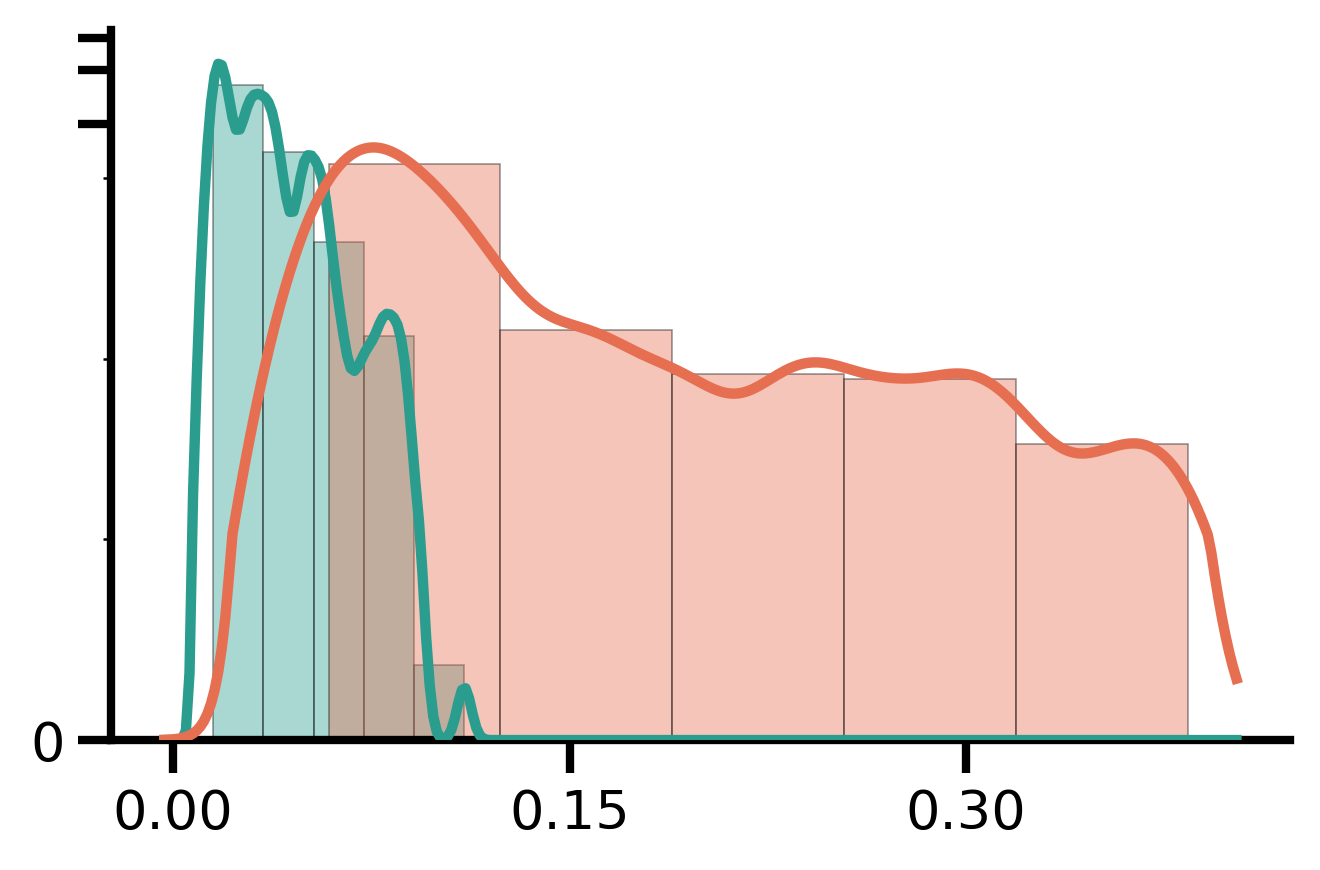

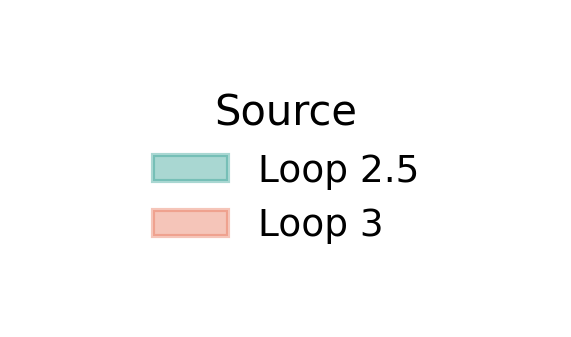

In [34]:
# Define the colour map matching the loop labels
cmap = {
    "Loop 2.5": "#2a9d8f",
    "Loop 3":   "#e76f51"
}

# ---- Guard: set True to subset each group to its top 5% by proportion ----
subset_top_5pct = True
top_percentile = 75

for mono, ct_dfs in ct_dfs_dict.items():
    print(mono)
    # Extract the proportion series
    prop25 = ct_dfs["Loop 2.5"][f"{mono}_prop"]
    prop3  = ct_dfs["Loop 3"][f"{mono}_prop"]

    # ---- Optionally subset to top X% by proportion (within each loop) ----
    if subset_top_5pct:
        thresh25 = np.percentile(prop25.values, top_percentile)
        thresh3  = np.percentile(prop3.values, top_percentile)
        prop25 = prop25[prop25 > thresh25]
        prop3  = prop3[prop3 > thresh3]
        print(f"\tLoop 2.5 threshold: {thresh25:.4f} -> {len(prop25)} kept")
        print(f"\tLoop 3 threshold:   {thresh3:.4f} -> {len(prop3)} kept")

    # Build the combined DataFrame that the function expects
    df_combined = pd.DataFrame({
        f"{mono}_prop": pd.concat([prop25, prop3], ignore_index=True),
        "Source":       ["Loop 2.5"] * len(prop25) + ["Loop 3"] * len(prop3)
    })
    # Call the distribution plotter
    plot_distribution(
        df=df_combined,
        col_name=f"{mono}_prop",        # column containing the values
        source_col="Source",            # column that identifies the loop
        loop0_key="Loop 2.5",           # key for the first group
        loop1_key="Loop 3",             # key for the second group
        bins=5,                         # number of histogram bins
        yscale='symlog',
        linthresh=0.1,
        xlabel=f"{mono} proportion",
        ylabel="Density (symlog scale)",
        save_path=f"output/{mono}_prop_distribution.png",   # optional
        legend_path=f"output/legend.png",
        figsize=(4.5, 3),
        remove_ax_titles=True
    )

## Parse Optimization Data to Retrieve Molecule Concentrations.

### Get Loop 2 Optimization Data.

In [15]:
X_loop2 = opt_df2_filt[protocol_cols2].values
X_log1p_loop2 = opt_df2_filt[resc_protocol_cols2].values

### Extend Loop2 Optimization Data with Additional Molecules.

In [16]:
extra_cols = set(protocol_cols3).difference(set(protocol_cols2))

X_loop2_ext = np.zeros((X_loop2.shape[0], X_loop2.shape[1] + len(extra_cols)))
X_loop2_ext[:, :X_loop2.shape[1]] = X_loop2

X_log1p_loop2_ext = np.zeros((X_loop2.shape[0], X_loop2.shape[1] + len(extra_cols)))
X_log1p_loop2_ext[:, :X_loop2.shape[1]] = X_log1p_loop2

### Get Loop 3 Optimization Data.

In [17]:
X_loop3 = opt_df3_filt[protocol_cols3].values
X_log1p_loop3 = opt_df3_filt[resc_protocol_cols3].values

### Get Loop 3 Optimization Data (Only Loop 2 Molecules).

In [18]:
X_loop3_subset = opt_df3_filt[protocol_cols2].values
X_log1p_loop3_subset = opt_df3_filt[resc_protocol_cols2].values

## Bootstrapped Distance Analysis on Shared Molecule Support.

### Bootstrap Distance Between Groups.

In [19]:
# --- Settings for bootstrap ----
n_bootstrap_iters = 500
n_samples_per_iter = 2_500

# ---- Store for bootstrapping results ----
all_dists_ref = []
all_dists_tgt = []

# --- Get number of optimization solutions ----
n_sol_loop2 = X_log1p_loop2.shape[0]
n_sol_loop3 = X_log1p_loop3.shape[0]

# ---- Iterate over bootstrapping steps ----
for it in tqdm(range(n_bootstrap_iters)):
    # --- Loop 2 optimization data ----
    loop2_ref_idxs = np.random.choice(n_sol_loop2, size=(n_samples_per_iter))
    loop2_query_idxs = np.random.choice(n_sol_loop2, size=(n_samples_per_iter))
    x_loop2_ref = X_log1p_loop2[loop2_ref_idxs]
    x_loop2_query = X_log1p_loop2[loop2_query_idxs]

    # --- Loop 3 optimization data ----
    loop3_idxs = np.random.choice(n_sol_loop3, size=(n_samples_per_iter))
    x_loop3 = X_log1p_loop3_subset[loop3_idxs]

    # ---- Compute distances between query, reference and target ----
    dist_ref = cdist(x_loop2_ref, x_loop2_query) # N x M
    dist_tgt = cdist(x_loop2_ref, x_loop3) # N x M

    # ---- Compute nearest neighbor distance from query data ----
    nn_dist_ref = dist_ref.min(0) # N x M -> N
    nn_dist_tgt = dist_tgt.min(0) # N x M -> N

    # ---- Update store for results ----
    all_dists_ref.append(nn_dist_ref)
    all_dists_tgt.append(nn_dist_tgt)

# ---- Concatenate results across bootstrap steps ---
all_dists_ref = np.stack(all_dists_ref, axis=0)
all_dists_tgt = np.stack(all_dists_tgt, axis=0)

# ---- Flatten nearest neighbor distances ---
dists_ref = all_dists_ref.flatten()
dists_tgt = all_dists_tgt.flatten()

# ---- Construct results DataFrame ----
dists_df = pd.DataFrame({"Within Loop 2": dists_ref, "Betweeen Loop 2 and Loop 3": dists_tgt})
dists_df


  0%|          | 0/500 [00:00<?, ?it/s]

100%|██████████| 500/500 [00:47<00:00, 10.56it/s]


,Within Loop 2,Betweeen Loop 2 and Loop 3
0,0.077225,1.061701
1,0.018952,0.914058
2,0.002088,1.586667
3,0.185713,0.570313
4,0.230231,0.706466
...,...,...
1249995,0.371121,0.346155
1249996,0.018877,0.396735
1249997,0.004135,0.546223
1249998,0.379996,0.576797


### Plot Distribution of Boostrapped Distances.

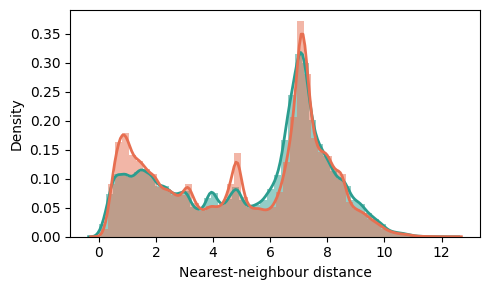

In [20]:
# ---- Flatten bootstrap arrays and remove exact zeros (self‑matches) ----
dist_ref_nonzero = dist_ref[dist_ref > 0]
dist_tgt_nonzero = dist_tgt[dist_tgt > 0]

# ---- Colours ----
color2 = "#2a9d8f"
color3 = "#e76f51"

# ---- Create figure with two subplots: histogram (left) and KDE (right) ----
fig, ax = plt.subplots(figsize=(5, 3))

# --- Histogram overlay ---
ax.hist(dist_ref_nonzero, bins=50, alpha=0.5, color=color2, density=True,
         label="Within Loop 2")
ax.hist(dist_tgt_nonzero, bins=50, alpha=0.5, color=color3, density=True,
         label="Loop 3 vs Loop 2")

# --- KDE overlay ---
sns.kdeplot(dist_ref_nonzero, ax=ax, color=color2, linewidth=2, label="Within Loop 2")
sns.kdeplot(dist_tgt_nonzero, ax=ax, color=color3, linewidth=2, label="Loop 3 vs Loop 2")

ax.set_xlabel("Nearest‑neighbour distance")
ax.set_ylabel("Density")

plt.tight_layout()
plt.show()

## Nearest Neighborhood Analysis.

### Apply Enrichment Filtering to Reduce Computational Complexity.

In [46]:
# ---- Define parameters for filtering ----
use_threshold = False
target_enrichment_goal = 0.05
percentile = 95
bounds_col = "passes_constraints:all"

# ---- Store for results ----
ct_dfs_filt_dict = {}

# ---- Iterate over the target monocytes ----
for mono, ct_dfs in ct_dfs_dict.items():
    # ---- Store for intermediate results ----
    loops_dict = {}

    # ---- Iterate over the experimental loops ----
    for loop, loop_df in ct_dfs.items():
        # ---- Compute enrichment mask for current data frame ----
        target_ct_prop = f"{mono}_prop"
        if use_threshold:
            enrichment_mask = loop_df[target_ct_prop] > target_enrichment_goal
        else:
            val = np.percentile(loop_df[target_ct_prop].values, percentile)
            print(f"{loop} -> {mono}: threshold val {val.item()}")
            enrichment_mask = loop_df[target_ct_prop] > val

        # ---- Compute joint mask and display results ----
        bounds_mask =  loop_df[bounds_col]
        mono_mask = enrichment_mask & bounds_mask

        # ---- Retrieve filtering informations and log message
        tot_candidates = len(mono_mask)
        n_bounds = bounds_mask.sum()
        n_enriching = enrichment_mask.sum()
        n_passing = mono_mask.sum()
        print(f"Passing filtering steps -> Enrichment: {n_enriching}/{tot_candidates}, Bounds: {n_bounds}/{tot_candidates}, Passing: {n_passing}/{tot_candidates}")

        # ---- Filter candidates ----
        filt_ct_df = loop_df[mono_mask].copy()
        loops_dict[loop] = filt_ct_df
    ct_dfs_filt_dict[mono] = loops_dict


Loop 2.5 -> CD14Mono: threshold val 0.01100240625
Passing filtering steps -> Enrichment: 581/11616, Bounds: 11616/11616, Passing: 581/11616
Loop 3 -> CD14Mono: threshold val 0.018687851349999986
Passing filtering steps -> Enrichment: 743/14852, Bounds: 14852/14852, Passing: 743/14852
Loop 2.5 -> CD16Mono: threshold val 0.043617180200000015
Passing filtering steps -> Enrichment: 1131/22617, Bounds: 22617/22617, Passing: 1131/22617
Loop 3 -> CD16Mono: threshold val 0.13109745250000002
Passing filtering steps -> Enrichment: 485/9684, Bounds: 9684/9684, Passing: 485/9684


### Compute Distances in Shared Space.

In [61]:
all_records = []

for mono, ct_dfs in ct_dfs_filt_dict.items():
    enrichment_col = f"{mono}_prop"

    loop2p5_df = ct_dfs["Loop 2.5"]
    loop3_df = ct_dfs["Loop 3"]

    y2p5 = loop2p5_df[enrichment_col].values
    y3 = loop3_df[enrichment_col].values

    x2p5 = loop2p5_df[resc_protocol_cols2].values
    x3 = loop3_df[resc_protocol_cols2].values

    D = cdist(x2p5, x3)

    D_min0 = D.min(0)
    D_argmin0 = D.argmin(0)
    x_nn_loop2 = x2p5[D_argmin0]
    y_nn_loop2 = y2p5[D_argmin0]

    delta_x = x3 - x_nn_loop2
    delta_y = y3 - y_nn_loop2

    n3 = x3.shape[0]
    
    for idx, d in enumerate(delta_x):
        all_records.append({
            **{col: d[idx].tolist() for idx, col in enumerate(protocol_cols2)}, 
            "Target Cell Type": mono,
            "Target Cell Type Enrichment": delta_y[idx]
            }
        )

delta_nn_df = pd.DataFrame(all_records)
delta_nn_df

,gm-csf_[ng_ml],tpo_[ng_ml],sr1_[nm],um171_[nm],um729_[µm],scf_[ng_ml],butyzamide_[nm],retinoic_acid_[µm],ldl_[ng_ml],il3_[ng_ml],o2_[%],days_of_culture,Target Cell Type,Target Cell Type Enrichment
0,0.003084,0.073917,0.536321,0.224543,0.322850,0.733148,-0.113637,-0.188062,0.110468,0.000000,-0.162544,0.047290,CD14Mono,0.007688
1,0.002713,0.076793,0.546278,0.205738,0.340052,0.652083,-0.114897,-0.191296,0.109186,0.000000,-0.153667,0.063530,CD14Mono,0.006585
2,0.070705,-0.037115,0.506759,-0.034865,0.604126,3.478309,-0.145509,-0.137921,0.053574,0.000000,-0.098591,0.065929,CD14Mono,0.012201
3,0.002713,0.076793,0.546278,0.205738,0.340052,0.652083,-0.114897,-0.191296,0.109186,0.000000,-0.153667,0.063530,CD14Mono,0.006585
4,0.070705,-0.037115,0.506759,-0.034865,0.604126,3.478309,-0.145509,-0.137921,0.053574,0.000000,-0.098591,0.065929,CD14Mono,0.012201
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1223,0.226151,0.795484,2.127123,6.931618,-0.046051,-0.030378,-1.864368,0.471351,0.000000,3.060879,-0.226406,0.326387,CD16Mono,0.080793
1224,0.809044,0.545095,2.054949,7.040105,-1.272536,0.045363,0.000000,-0.585593,0.271325,0.184750,-0.419988,-0.015891,CD16Mono,0.119788
1225,0.627315,0.345123,-0.573797,0.000000,-1.176009,0.980263,0.000000,-0.324834,-0.285223,0.002274,-0.580005,-0.193625,CD16Mono,0.088380
1226,0.586390,0.327575,-0.743810,0.014646,-1.108743,0.950052,0.000000,-0.336546,-0.261865,0.000000,-0.526875,-0.258361,CD16Mono,0.081520


### Function to Plot a Single Distribution with Histogram and KDE Plot.

In [77]:
def plot_single_distribution(
    data,
    color="#2a9d8f",
    bins=20,
    figsize=(4.5, 3),
    dpi=300,
    save_path=None,
    legend_path=None,
    xlabel=None,
    ylabel="Density (symlog scale)",
    title=None,
    yscale='symlog',
    linthresh=0.1,
    naked=False,
    remove_ax_titles=True,
):
    """
    Plot a single distribution with histogram + KDE, in the same style
    as the original `plot_distribution` (two‑group version).

    Parameters
    ----------
    data : array-like
        The values to plot.
    color : str
        Hex colour for the distribution.
    bins : int
        Number of histogram bins.
    figsize : tuple
        Figure size in inches.
    dpi : int
        Resolution.
    save_path : str or None
        If provided, save the main figure to this path.
    legend_path : str or None
        If provided, save a separate legend figure (with one patch).
    xlabel, ylabel, title : str or None
        Axis labels and title. If None, no label/title.
    yscale : str
        Scale for y-axis ('symlog', 'log', 'linear').
    linthresh : float
        Threshold for symlog (ignored if yscale != 'symlog').
    naked : bool
        If True, remove all axis labels and ticks.
    remove_ax_titles : bool
        If True, remove axis labels and title (overrides given labels).
    """
    data = np.asarray(data).flatten()

    # ----- figure -----
    plt.figure(figsize=figsize, dpi=dpi, facecolor='white')
    ax = plt.gca()
    ax.set_facecolor('white')

    # histogram
    ax.hist(data, bins=bins, density=True, alpha=0.4,
            facecolor=color, edgecolor='black', linewidth=0.4, zorder=2)

    # KDE
    x_min, x_max = data.min(), data.max()
    pad = 0.05 * (x_max - x_min) if x_max != x_min else 0.1
    x_grid = np.linspace(x_min - pad, x_max + pad, 300)
    kde = gaussian_kde(data)
    ax.plot(x_grid, kde(x_grid), color=color, linewidth=2.5, zorder=3)

    # y-scale
    if yscale == 'symlog':
        ax.set_yscale('symlog', linthresh=linthresh)
    else:
        ax.set_yscale(yscale)

    # ----- styling -----
    if naked:
        for spine in ax.spines.values():
            spine.set_visible(True)
            spine.set_linewidth(2.5)
        ax.tick_params(axis='both', which='major',
                       length=8, width=2, color='black',
                       labelleft=False, labelbottom=False)
        if remove_ax_titles:
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title('')
    else:
        for spine in ax.spines.values():
            spine.set_linewidth(2)
        sns.despine()
        ax.xaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.yaxis.set_major_locator(ticker.MaxNLocator(nbins=4))
        ax.tick_params(axis='both', which='major',
                       labelsize=10, length=6, width=1.5)
        if not remove_ax_titles:
            ax.set_xlabel(xlabel if xlabel else '', fontsize=14, fontweight='bold')
            ax.set_ylabel(ylabel if ylabel else '', fontsize=14, fontweight='bold')
            ax.set_title(title if title else '', fontsize=14, fontweight='bold')
        else:
            ax.set_xlabel('')
            ax.set_ylabel('')
            ax.set_title('')

    plt.tight_layout()
    if save_path:
        plt.savefig(save_path, bbox_inches='tight', dpi=dpi)
    plt.show()

    # Optional legend (single patch)
    if legend_path:
        import matplotlib.patches as mpatches
        leg_patch = mpatches.Patch(color=color, alpha=0.4, label=xlabel or 'Distribution')
        fig_leg = plt.figure(figsize=(2, 1.2), dpi=dpi)
        ax_leg = fig_leg.add_subplot(111)
        ax_leg.axis('off')
        ax_leg.legend(handles=[leg_patch], loc='center', frameon=False, fontsize=9)
        fig_leg.savefig(legend_path, bbox_inches='tight', dpi=dpi)
        plt.show()

### Plot Distribution of Difference in Target Enrichment.

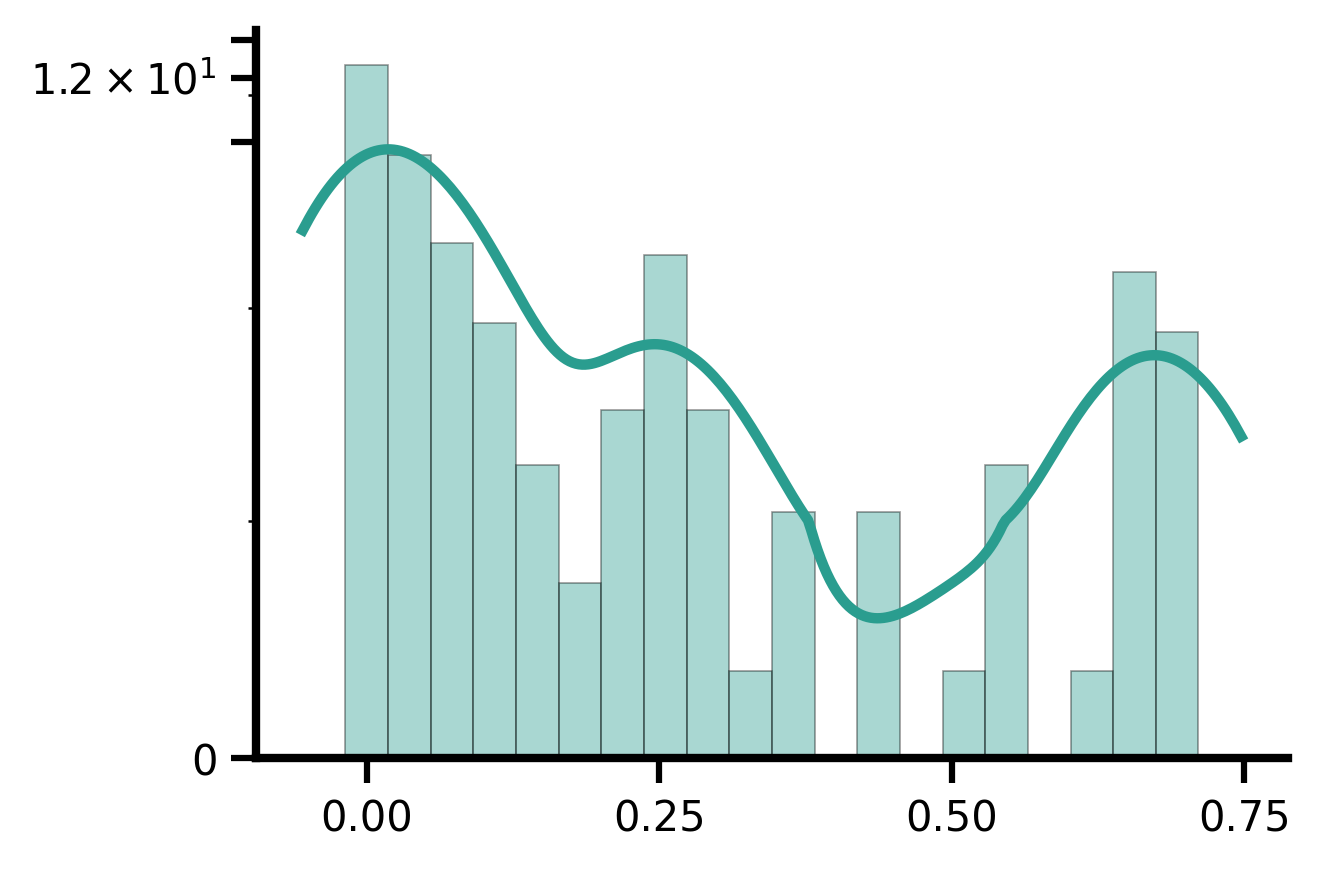

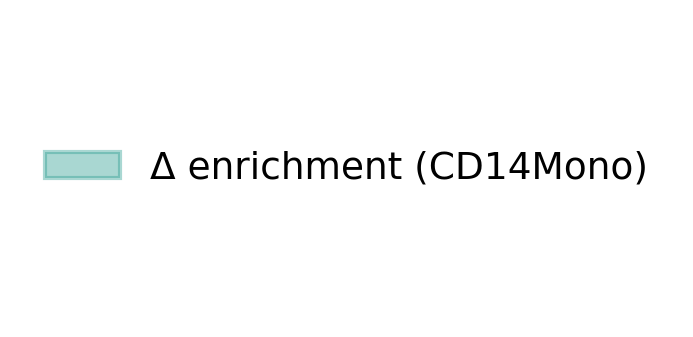

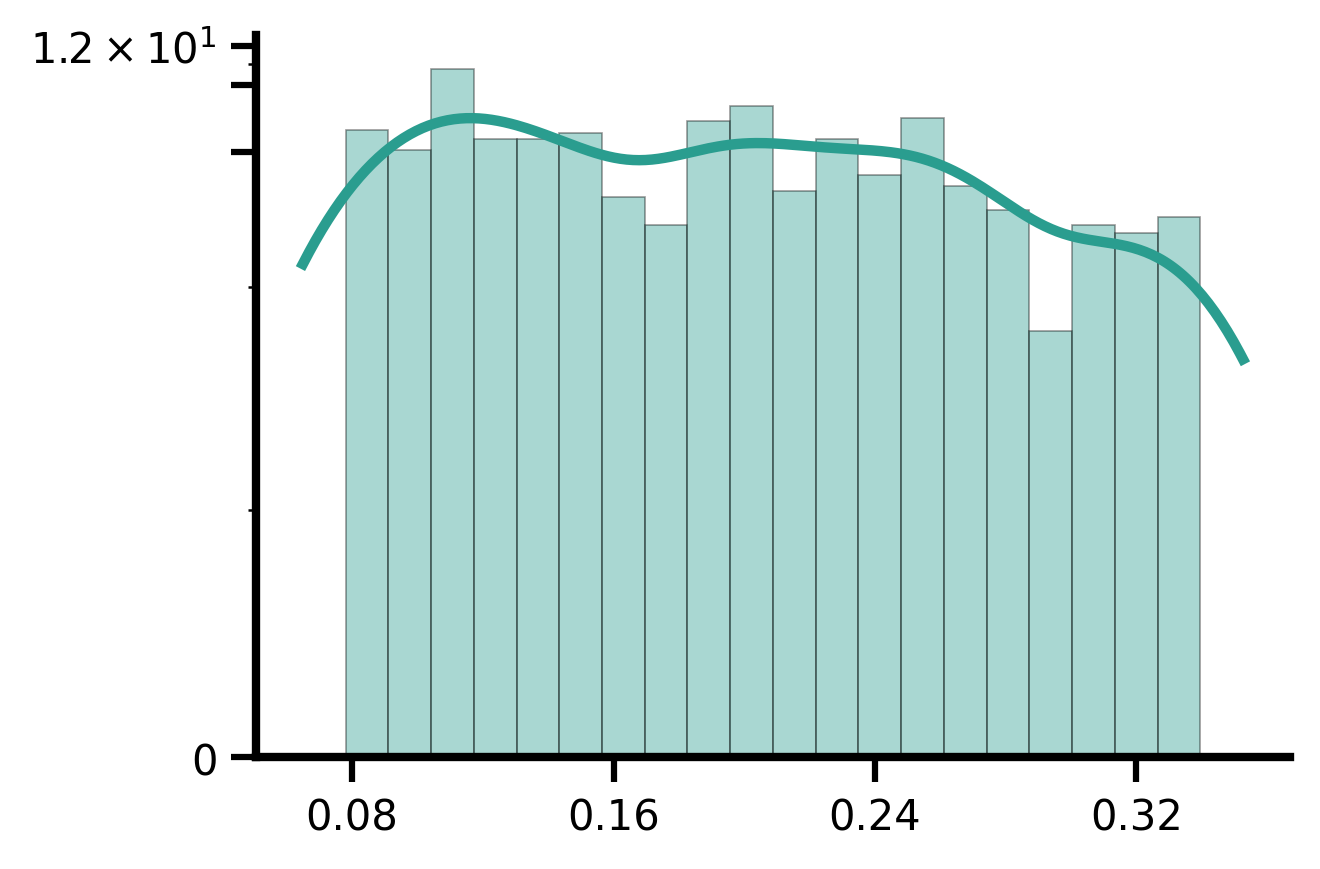

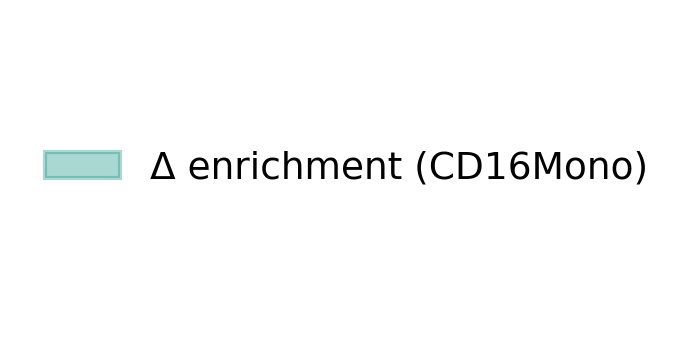

In [81]:
# Iterate over targets and plot delta enrichment
for target, group in delta_nn_df.groupby("Target Cell Type"):
    plot_single_distribution(
        data=group["Target Cell Type Enrichment"],
        color="#2a9d8f",                # same as your Loop 2.5 colour
        bins=20,
        yscale='symlog',
        linthresh=0.1,
        xlabel=f"Δ enrichment ({target})",
        ylabel="Density (symlog scale)",
        title=f"Delta enrichment – {target}",
        save_path=f"output/delta_enrichment_{target}.png",
        legend_path=f"output/delta_legend_{target}.png",  # optional
        figsize=(4.5, 3),
        remove_ax_titles=True,          # show labels this time
        naked=False
    )


### Scatter Plot of Distance in Concentration Space against Delta in Target Enrichment.

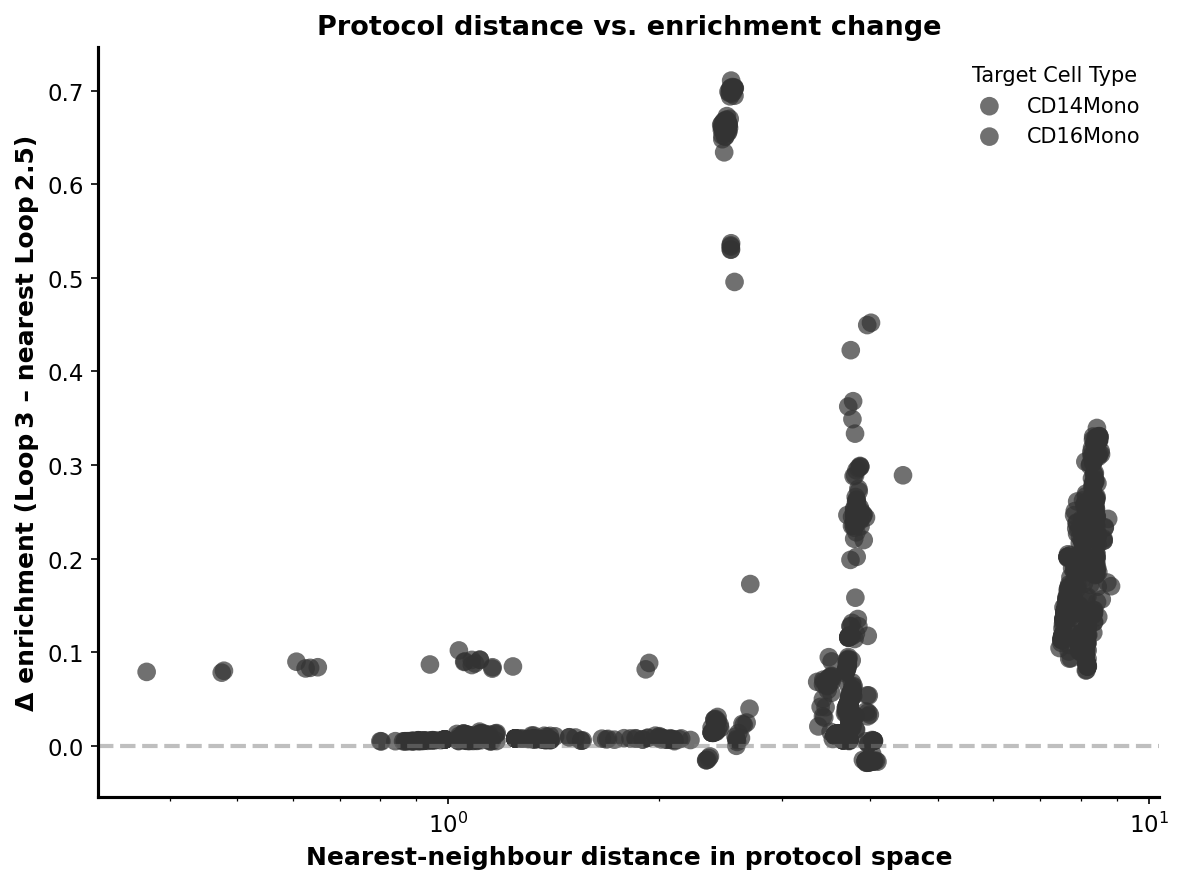

In [89]:
# ------------------------------------------------------------------
# Compute nearest‑neighbour distances and add as a column to delta_nn_df
# ------------------------------------------------------------------
nn_distances = []

for mono, ct_dfs in ct_dfs_filt_dict.items():
    loop2p5 = ct_dfs["Loop 2.5"]
    loop3   = ct_dfs["Loop 3"]

    X2 = loop2p5[resc_protocol_cols2].values
    X3 = loop3[resc_protocol_cols2].values

    D = cdist(X3, X2)
    nn_dist = D.min(axis=1)                     # one distance per Loop 3 solution

    nn_distances.extend(nn_dist.tolist())

# Add the distances as a new column (order matches delta_nn_df rows)
delta_nn_df["nn_distance"] = nn_distances

# ------------------------------------------------------------------
# Scatter plot: nn_distance vs enrichment delta
# ------------------------------------------------------------------
target_palette = {
    "MgkPro": "#669bbc",
    "HSC": "#780000",
    "Erythroid": "#f4a261",
    "PreProB": "#9b5de5"
}

fig, ax = plt.subplots(figsize=(8, 6), dpi=150)

for target in target_cts:
    subset = delta_nn_df[delta_nn_df["Target Cell Type"] == target]
    ax.scatter(
        subset["nn_distance"],
        subset["Target Cell Type Enrichment"],
        color=target_palette.get(target, "#333333"),
        alpha=0.7,
        s=80,
        label=target,
        edgecolors='none'
    )

# Horizontal reference line
ax.axhline(0, color="gray", linewidth=2, alpha=0.5, linestyle="--")

ax.set_xlabel("Nearest‑neighbour distance in protocol space", fontsize=12, fontweight='bold')
ax.set_ylabel("Δ enrichment (Loop 3 – nearest Loop 2.5)", fontsize=12, fontweight='bold')
ax.set_title("Protocol distance vs. enrichment change", fontsize=13, fontweight='bold')

ax.set_xscale("log")

for spine in ax.spines.values():
    spine.set_linewidth(1.5)
sns.despine()
ax.tick_params(labelsize=11)
ax.legend(title="Target Cell Type", fontsize=10, frameon=False)

plt.tight_layout()
plt.show()


### Stripplot of Resulting Differences in Condition Space per Molecule.

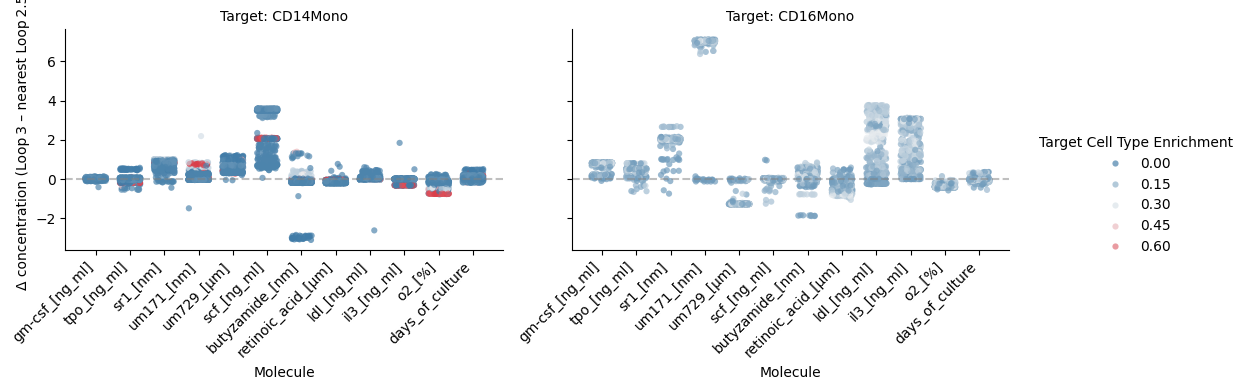

In [75]:
# ------------------------------------------------------------------
# 1. Melt wide to long (one row per molecule per solution)
# ------------------------------------------------------------------
melted = pd.melt(
    delta_nn_df,
    id_vars=['Target Cell Type', 'Target Cell Type Enrichment'],
    value_vars=protocol_cols2,        # your list of molecule columns
    var_name='Molecule',
    value_name='delta_x'
)

# ------------------------------------------------------------------
# 2. Jittered x-coordinates (replaces categorical stripplot)
# ------------------------------------------------------------------
molecule_codes, molecule_labels = pd.factorize(melted['Molecule'])
melted['x_code'] = molecule_codes
rng = np.random.default_rng(42)
melted['x_jittered'] = melted['x_code'] + rng.uniform(-0.3, 0.3, size=len(melted))

# ------------------------------------------------------------------
# 3. Faceted jittered scatter with continuous hue = enrichment delta
# ------------------------------------------------------------------
# Diverging colormap: blue (lower) → white (no change) → red (higher)
cmap = sns.diverging_palette(240, 10, as_cmap=True)

g = sns.relplot(
    data=melted,
    x='x_jittered',
    y='delta_x',
    hue='Target Cell Type Enrichment',   # continuous colour
    col='Target Cell Type',              # one panel per target
    palette=cmap,
    # hue_norm=(0, 1),               # adjust to your delta_y range
    edgecolor='none',
    s=20,
    alpha=0.7,
    height=4,
    aspect=1.3,
    col_wrap=2,                          # panels per row (adjust to taste)
    legend=True
)

# Replace numbers with molecule names, add a zero reference line
for ax in g.axes.flat:
    ax.set_xticks(range(len(molecule_labels)))
    ax.set_xticklabels(molecule_labels, rotation=45, ha='right')
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)

g.set_axis_labels('Molecule', 'Δ concentration (Loop 3 – nearest Loop 2.5)')
g.set_titles('Target: {col_name}')
g.tight_layout()
plt.show()

### Scatter Plot of Shared Molecules againts Target Enrichment.

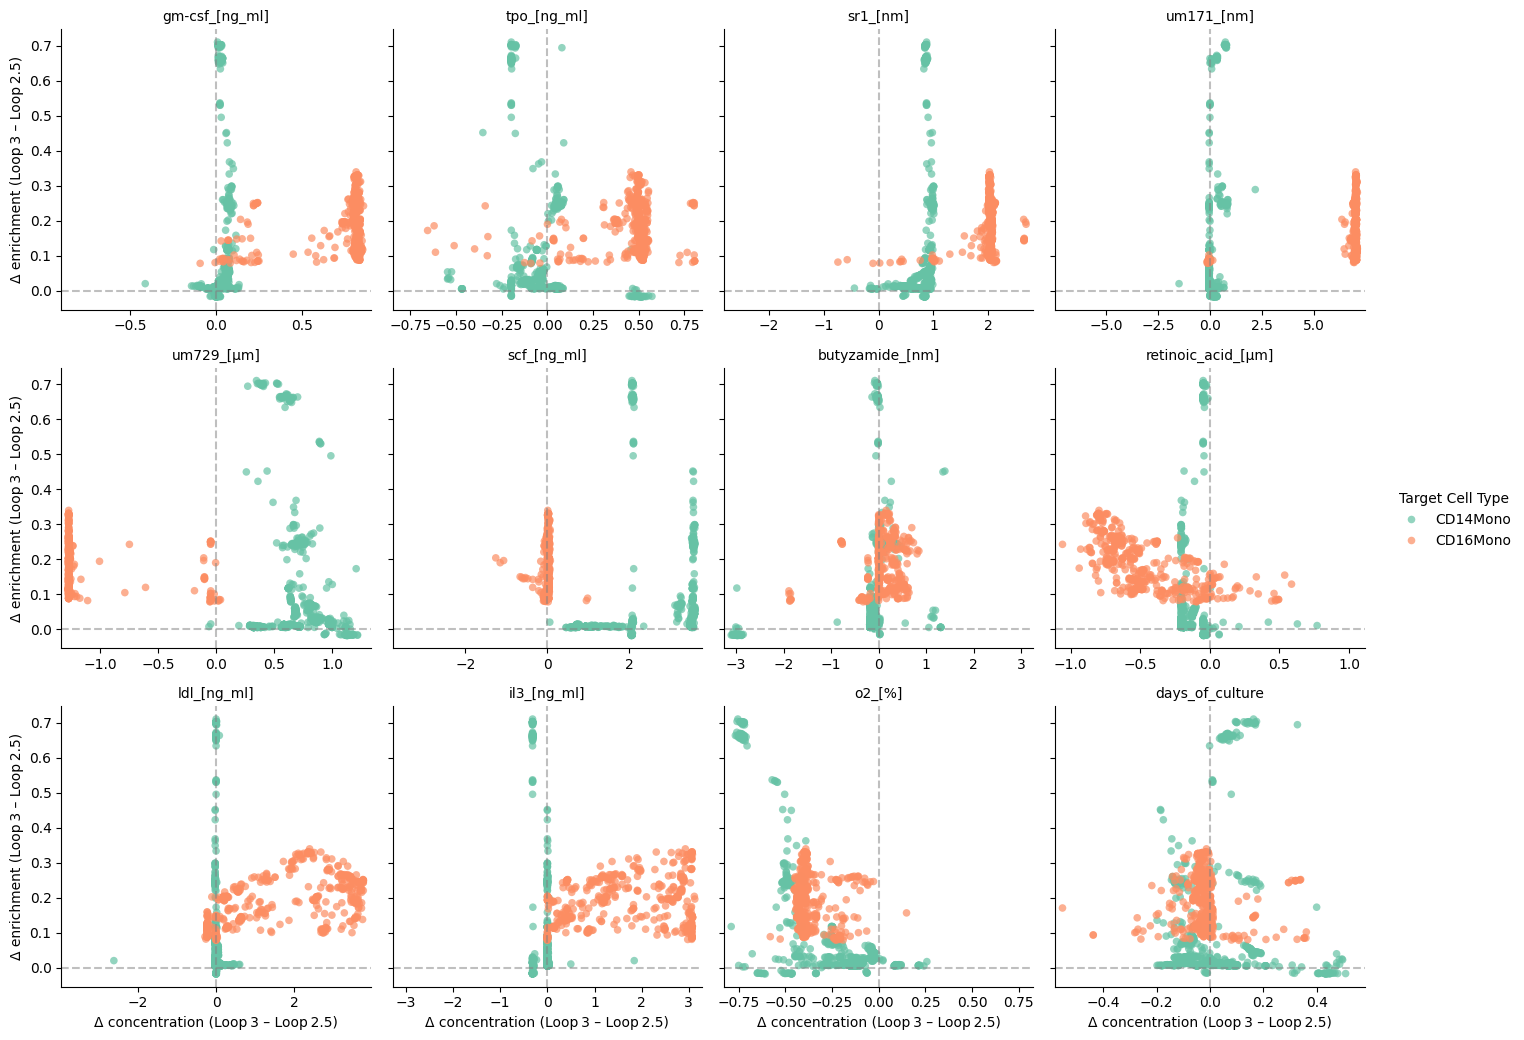

In [91]:
# ------------------------------------------------------------------
# Scatter per molecule: delta_x vs. enrichment delta, centered on 0
# ------------------------------------------------------------------
g = sns.relplot(
    data=melted,
    x='delta_x',
    y='Target Cell Type Enrichment',
    hue='Target Cell Type',
    col='Molecule',
    palette='Set2',                # or your own target_palette
    alpha=0.7,
    s=30,
    edgecolor='none',
    height=3.5,
    aspect=1,
    col_wrap=4,
    facet_kws={'sharex': False, 'sharey': True}
)

# Center each subplot on zero and add vertical reference line
for ax, mol_name in zip(g.axes.flat, g.col_names):
    # Filter the data for this molecule to get the actual x range
    mol_data = melted[melted['Molecule'] == mol_name]['delta_x']
    if len(mol_data) > 0:
        xmax = max(abs(mol_data.min()), abs(mol_data.max()))
        # Add a small pad (5%) so points are not exactly on the edge
        pad = xmax * 0.05 if xmax != 0 else 0.1
        ax.set_xlim(-xmax - pad, xmax + pad)
    # Dashed vertical line at x = 0
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)

# Horizontal reference line (unchanged)
for ax in g.axes.flat:
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)

g.set_axis_labels('Δ concentration (Loop 3 – Loop 2.5)',
                  'Δ enrichment (Loop 3 – Loop 2.5)')
g.set_titles('{col_name}')
g.tight_layout()
plt.show()


### Scatter Plot of Additional Molecules againts Target Enrichment.


In [92]:
# New molecules = those only in Loop 3
new_mols = [m for m in protocol_cols3 if m not in protocol_cols2]
resc_new_mols = [f"{m}:rescaled" for m in new_mols]
print("New molecules:", new_mols)

new_records = []

for mono, ct_dfs in ct_dfs_filt_dict.items():
    enrichment_col = f"{mono}_prop"

    loop2p5 = ct_dfs["Loop 2.5"]
    loop3   = ct_dfs["Loop 3"]

    y2 = loop2p5[enrichment_col].values
    y3 = loop3[enrichment_col].values

    # Find nearest Loop 2.5 neighbour for each Loop 3 recipe (using old molecules)
    X2 = loop2p5[resc_protocol_cols2].values      # only old molecules
    X3 = loop3[resc_protocol_cols2].values        # same old subset

    D = cdist(X3, X2)
    nn_idx = D.argmin(axis=1)
    y_nn = y2[nn_idx]
    delta_y = y3 - y_nn

    # For each solution, record the concentration of each new molecule
    for i in range(len(loop3)):
        for mol, resc_mol in zip(new_mols, resc_new_mols):
            conc = loop3[resc_mol].iloc[i]        # rescaled concentration
            new_records.append({
                "Target":     mono,
                "Solution":   i,
                "Molecule":   mol,
                "concentration": conc,
                "delta_y":    delta_y[i]
            })

new_mol_df = pd.DataFrame(new_records)
new_mol_df.head()

New molecules: ['il7_[ng_ml]', 'mcsf_[ng_ml]', 'ly_cocktail_[ul/well]']


,Target,Solution,Molecule,concentration,delta_y
0,CD14Mono,0,il7_[ng_ml],0.0,0.007688
1,CD14Mono,0,mcsf_[ng_ml],0.0,0.007688
2,CD14Mono,0,ly_cocktail_[ul/well],0.0,0.007688
3,CD14Mono,1,il7_[ng_ml],0.0,0.006585
4,CD14Mono,1,mcsf_[ng_ml],0.0,0.006585


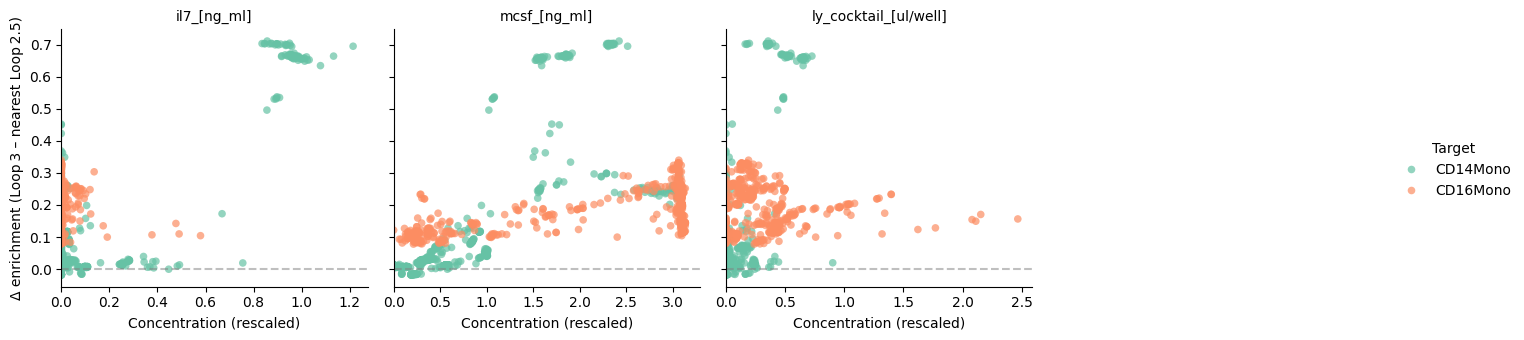

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Faceted plot: concentration vs enrichment delta, coloured by target cell type
g = sns.relplot(
    data=new_mol_df,
    x='concentration',
    y='delta_y',
    hue='Target',
    col='Molecule',
    palette='Set2',          # or your own target palette
    alpha=0.7,
    s=30,
    edgecolor='none',
    height=3.5,
    aspect=1,
    col_wrap=4,
    facet_kws={'sharex': False, 'sharey': True}
)

# Adjust each panel: x‑axis from 0 to max, vertical reference at 0, horizontal at 0
for ax, mol in zip(g.axes.flat, g.col_names):
    mol_data = new_mol_df[new_mol_df['Molecule'] == mol]['concentration']
    if len(mol_data) > 0:
        max_val = mol_data.max()
        # Add 5% padding
        ax.set_xlim(0, max_val * 1.05)
    ax.axvline(0, color='grey', linestyle='--', alpha=0.5)
    ax.axhline(0, color='grey', linestyle='--', alpha=0.5)

g.set_axis_labels('Concentration (rescaled)',
                  'Δ enrichment (Loop 3 – nearest Loop 2.5)')
g.set_titles('{col_name}')
g.tight_layout()
plt.show()